# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) using Machine Learning
**Dataset:** UNSW-NB15 (subset: 40k train / 10k test)  
**Task:** Binary Classification — Normal vs Attack

---
## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    confusion_matrix, precision_recall_curve, auc, classification_report
)
from sklearn.utils import resample

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully.')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully.
TensorFlow version: 2.21.0


---
## 1. Load Data

In [2]:
# Load training and testing datasets
train_df = pd.read_csv('UNSW_NB15_train_40k.csv')
test_df  = pd.read_csv('UNSW_NB15_test_10k.csv')

print('Training set shape :', train_df.shape)
print('Testing  set shape :', test_df.shape)
print('\nColumns:', list(train_df.columns))

Training set shape : (40000, 16)
Testing  set shape : (10000, 16)

Columns: ['proto', 'state', 'service', 'dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt', 'label']


---
## Task (i) — Exploratory Data Analysis (EDA)

In [3]:
# ── 1.1 Basic Structure ──────────────────────────────────────────────────────
print('=== DATA TYPES & FIRST 5 ROWS ===')
display(train_df.head())
print('\n=== INFO ===')
train_df.info()

=== DATA TYPES & FIRST 5 ROWS ===


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   proto    40000 non-null  object 
 1   state    40000 non-null  object 
 2   service  40000 non-null  object 
 3   dur      40000 non-null  float64
 4   sbytes   40000 non-null  int64  
 5   dbytes   40000 non-null  int64  
 6   spkts    40000 non-null  int64  
 7   dpkts    40000 non-null  int64  
 8   sload    40000 non-null  float64
 9   dload    40000 non-null  float64
 10  sttl     40000 non-null  int64  
 11  dttl     40000 non-null  int64  
 12  smean    40000 non-null  int64  
 13  dmean    40000 non-null  int64  
 14  sinpkt   40000 non-null  float64
 15  label    40000 non-null  int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 4.9+ MB


In [4]:
# ── 1.2 Statistical Summary ──────────────────────────────────────────────────
print('=== NUMERICAL FEATURE STATISTICS ===')
display(train_df.describe())

=== NUMERICAL FEATURE STATISTICS ===


,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000
max,59.999989,1.202983e+07,1.465555e+07,9094.000000,10974.000000,5.988000e+09,2.235302e+07,255.00000,254.000000,1504.000000,1458.000000,84371.496000,1.000000


In [5]:
# ── 1.3 Missing Values ───────────────────────────────────────────────────────
missing = train_df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


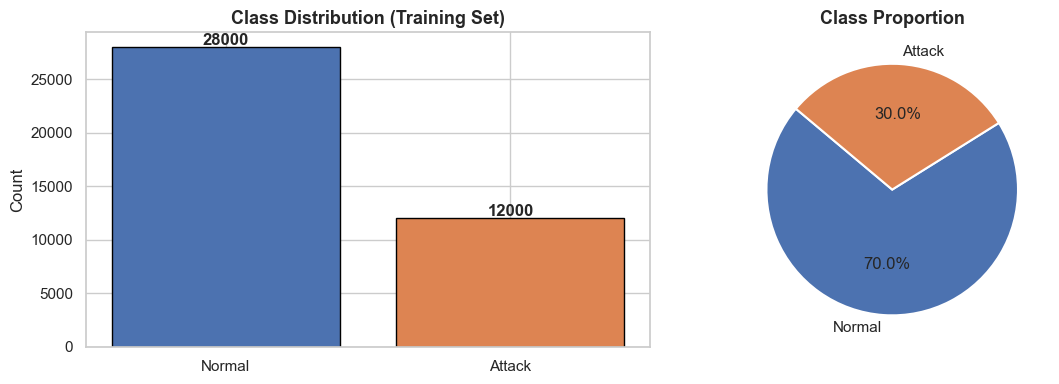

label
Normal    28000
Attack    12000
Name: count, dtype: int64

Imbalance ratio (majority:minority): 2.33:1


In [6]:
# ── 1.4 Class Distribution ───────────────────────────────────────────────────
label_map = {0: 'Normal', 1: 'Attack'}
class_counts = train_df['label'].map(label_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Class Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

print(class_counts)
ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (majority:minority): {ratio:.2f}:1')

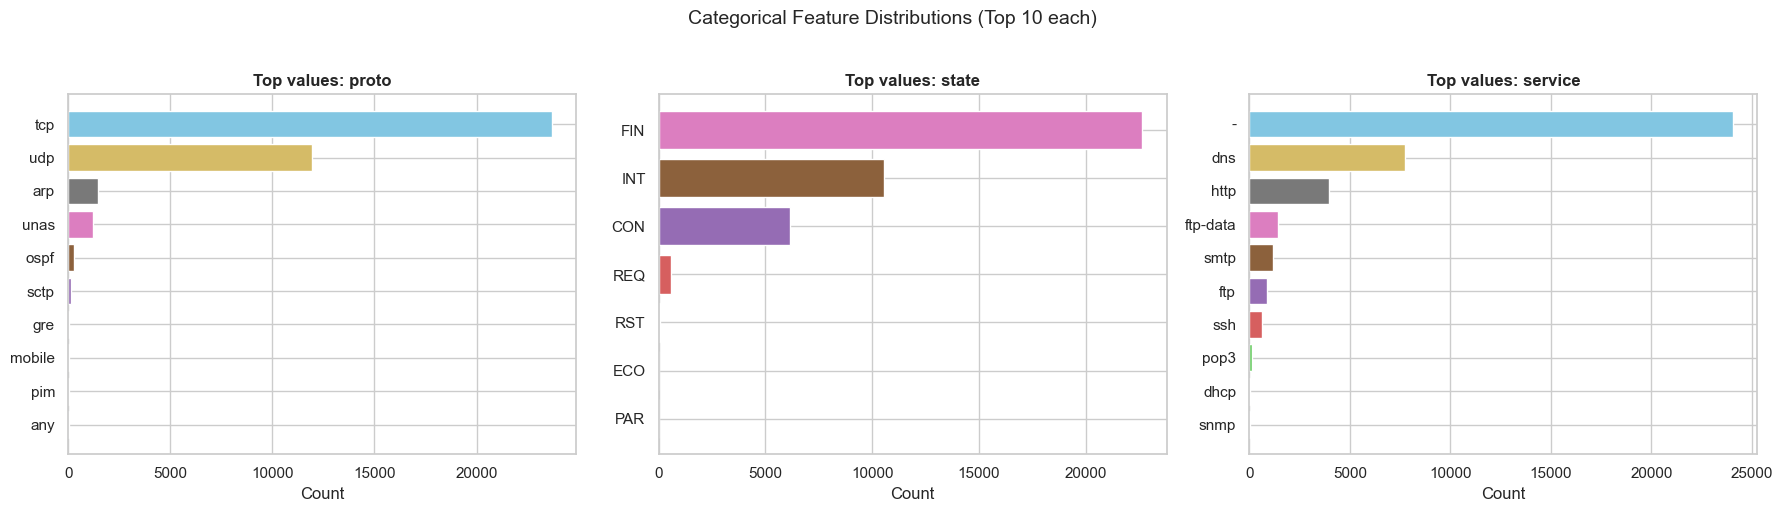

proto: 133 unique values — ['pri-enc', 'tcp', 'udp', 'unas', 'trunk-2', 'xns-idp', 'icmp', 'arp']
state: 7 unique values — ['INT', 'FIN', 'REQ', 'CON', 'ECO', 'RST', 'PAR']
service: 13 unique values — ['-', 'smtp', 'ftp-data', 'dns', 'http', 'ssh', 'ftp', 'pop3']


In [7]:
# ── 1.5 Categorical Feature Analysis ─────────────────────────────────────────
cat_cols = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top_vals = train_df[col].value_counts().head(10)
    ax.barh(top_vals.index[::-1], top_vals.values[::-1],
            color=sns.color_palette('muted', len(top_vals)))
    ax.set_title(f'Top values: {col}', fontweight='bold')
    ax.set_xlabel('Count')
plt.suptitle('Categorical Feature Distributions (Top 10 each)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_categorical_features.png', bbox_inches='tight')
plt.show()

for col in cat_cols:
    print(f'{col}: {train_df[col].nunique()} unique values — {list(train_df[col].unique()[:8])}')

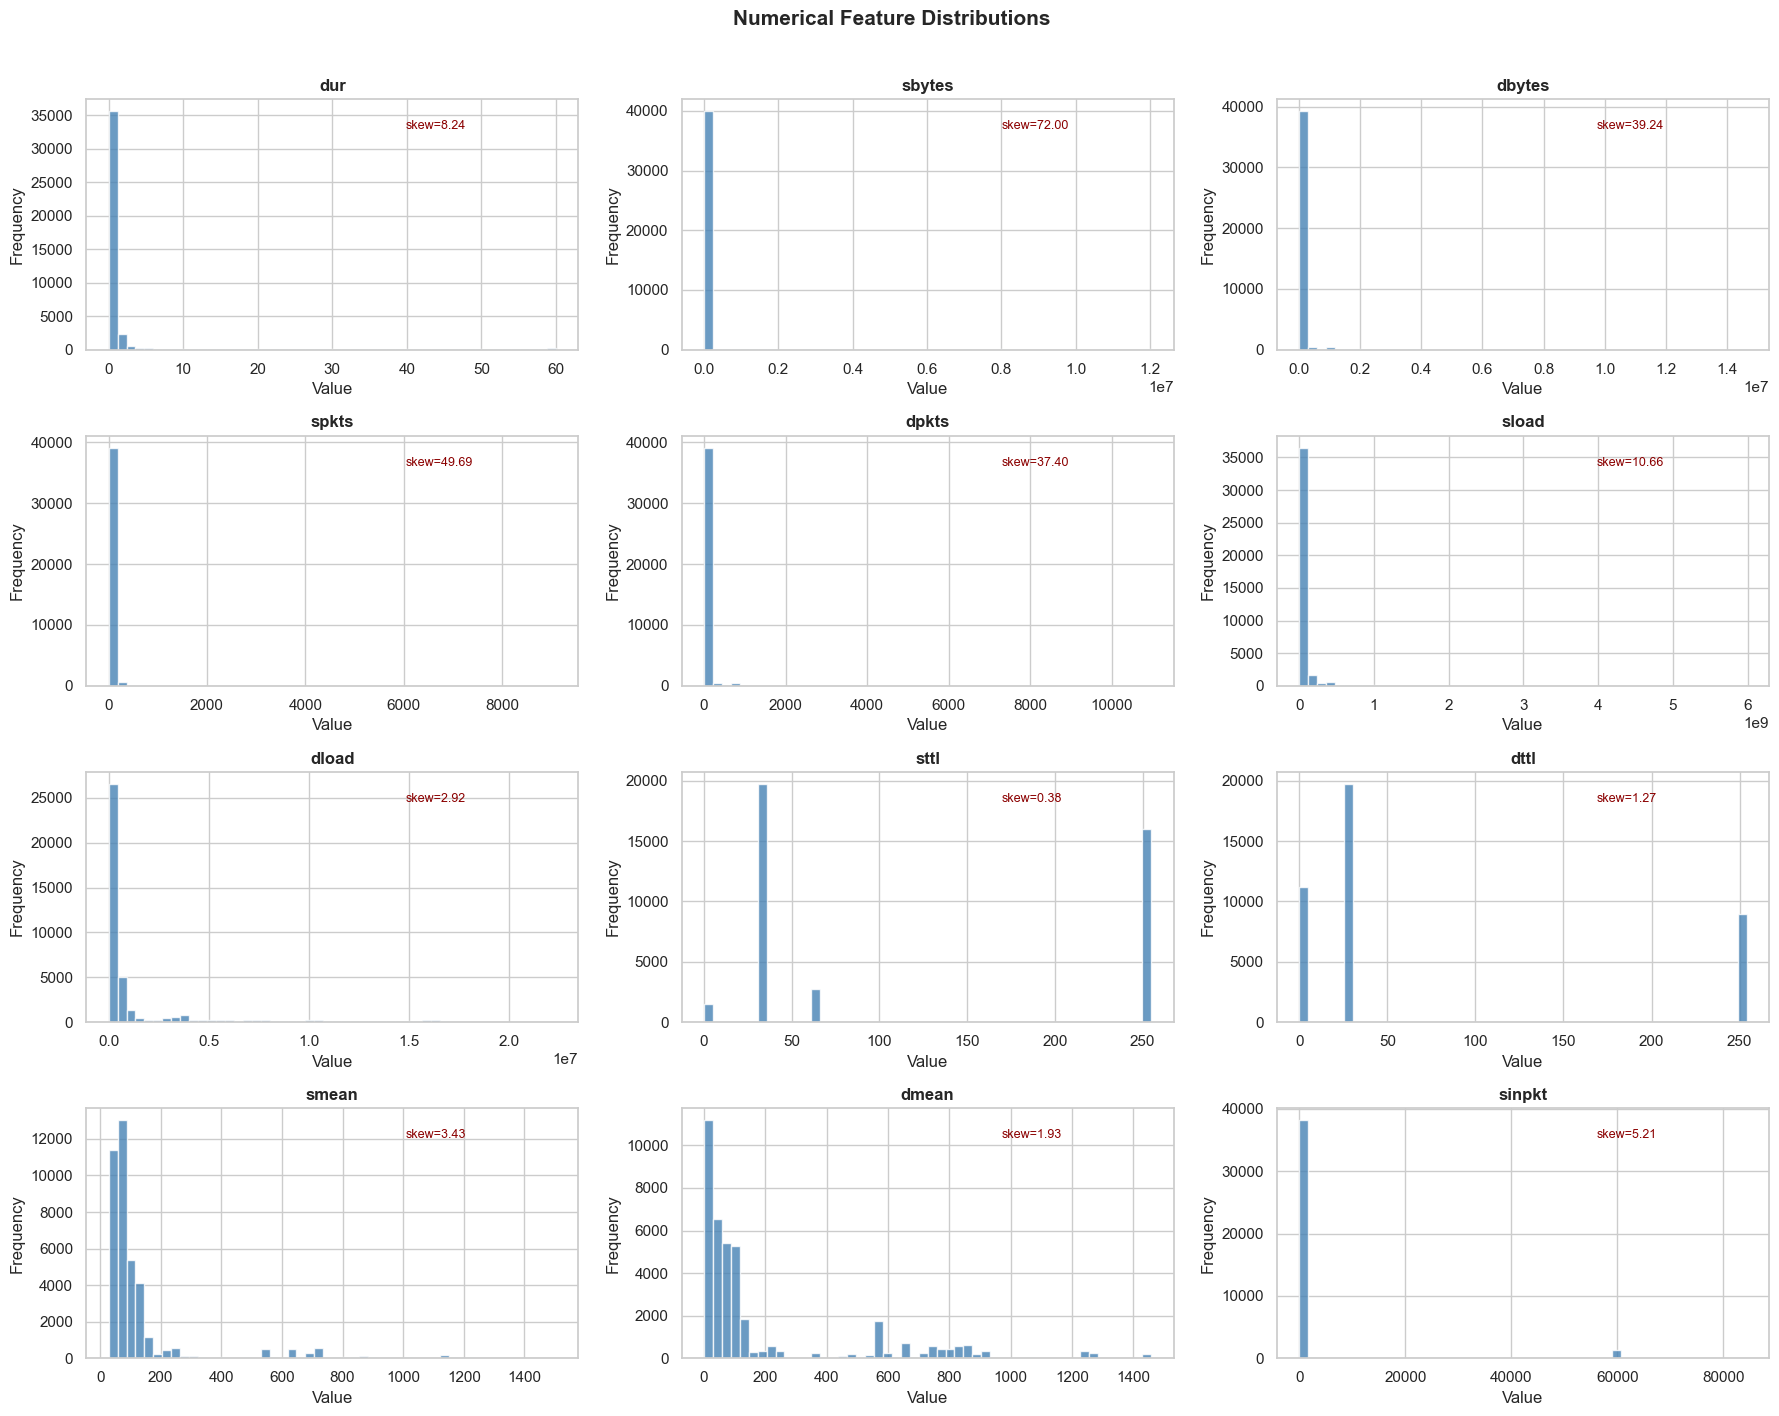

In [8]:
# ── 1.6 Numerical Feature Distributions ──────────────────────────────────────
num_cols = [c for c in train_df.columns if c not in cat_cols + ['label']]
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    skew_val = train_df[col].skew()
    axes[i].annotate(f'skew={skew_val:.2f}', xy=(0.65, 0.88),
                     xycoords='axes fraction', fontsize=9,
                     color='darkred')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_num_distributions.png', bbox_inches='tight')
plt.show()

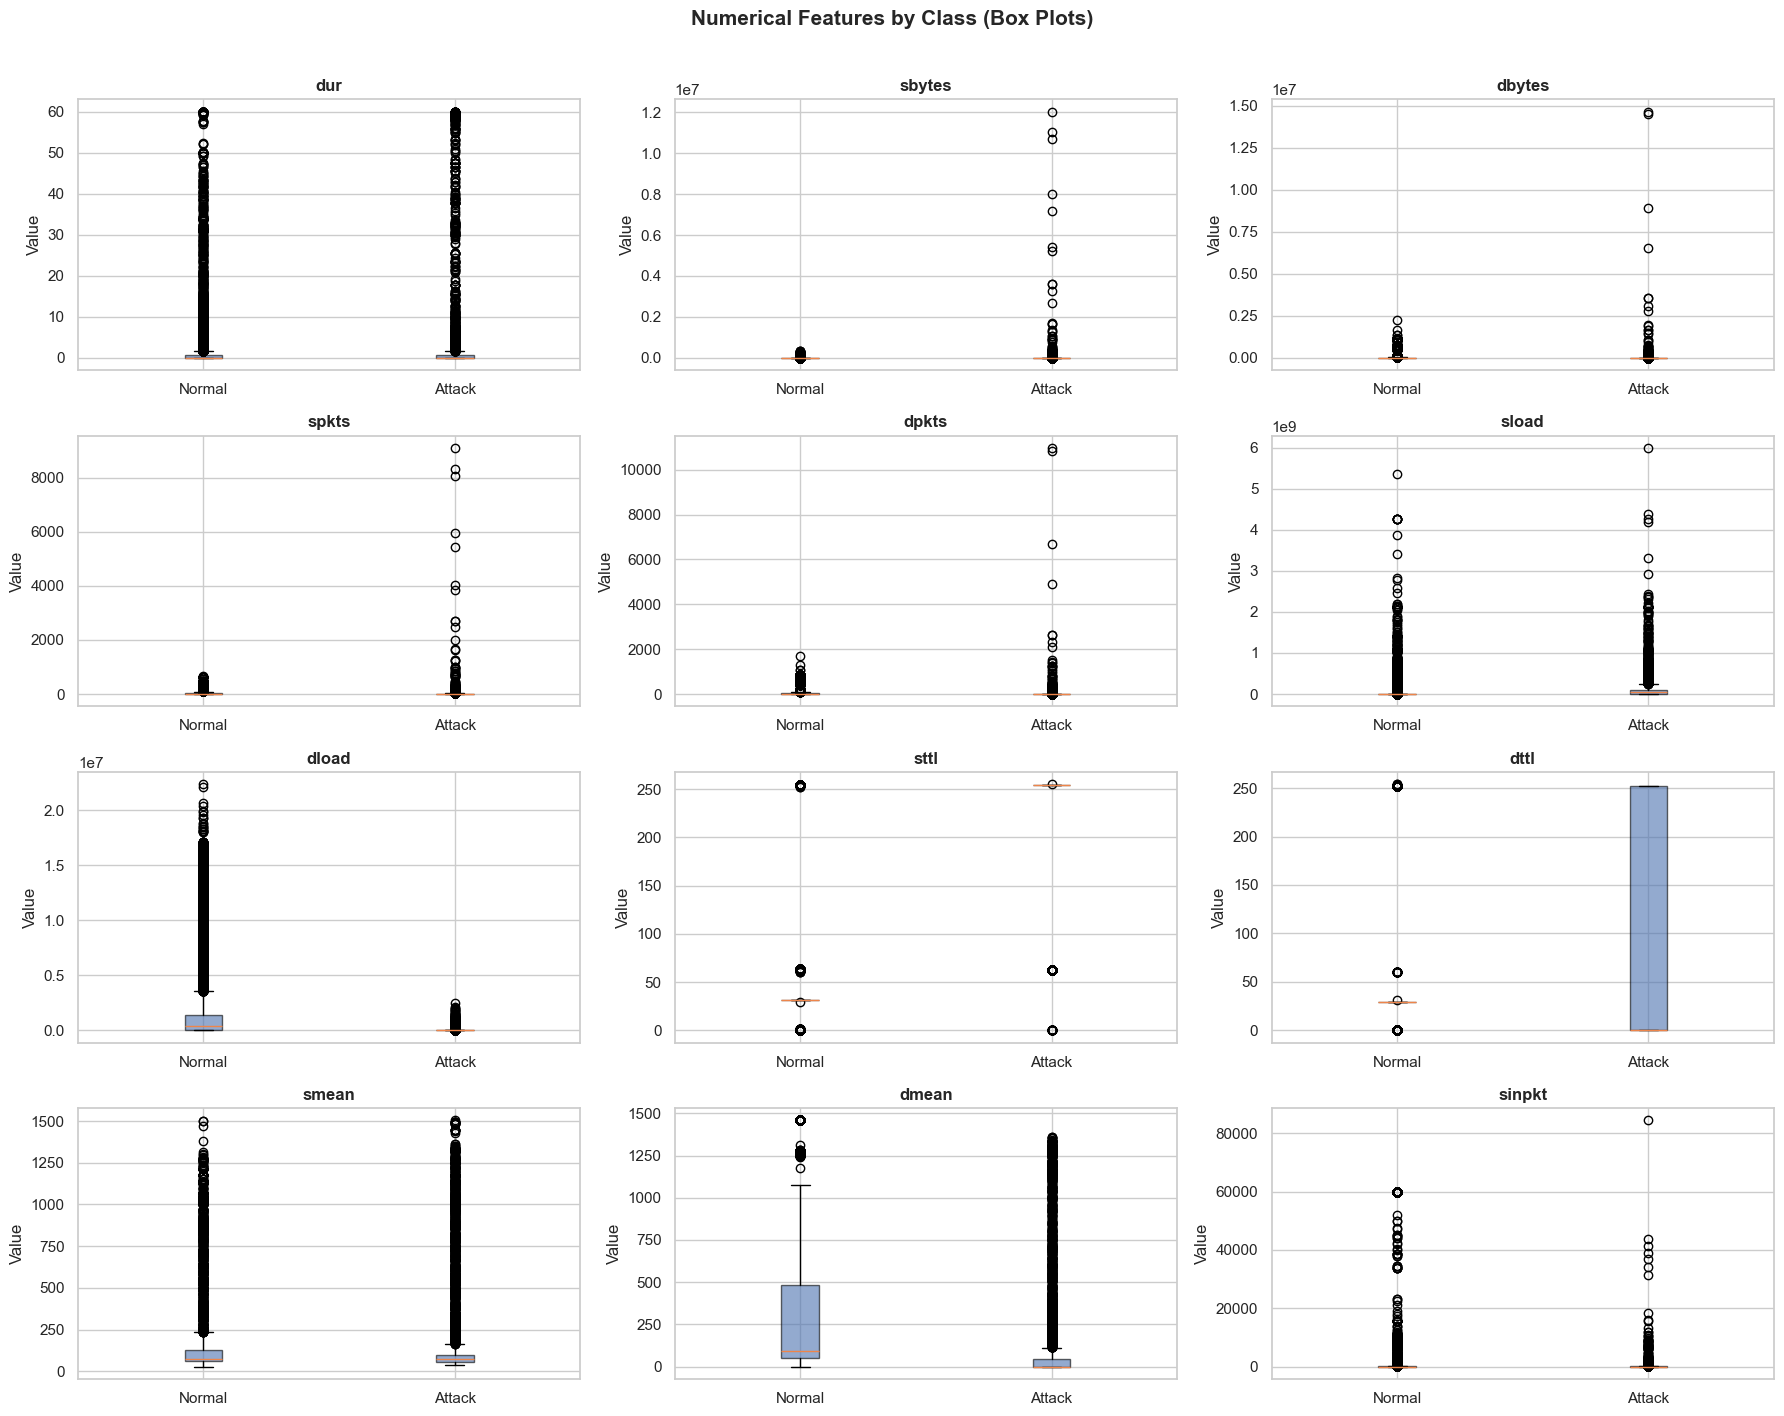

In [9]:
# ── 1.7 Feature vs Label (Box Plots) ─────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = train_df[train_df['label'] == 0][col]
    data_1 = train_df[train_df['label'] == 1][col]
    axes[i].boxplot([data_0, data_1], labels=['Normal', 'Attack'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Class (Box Plots)', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

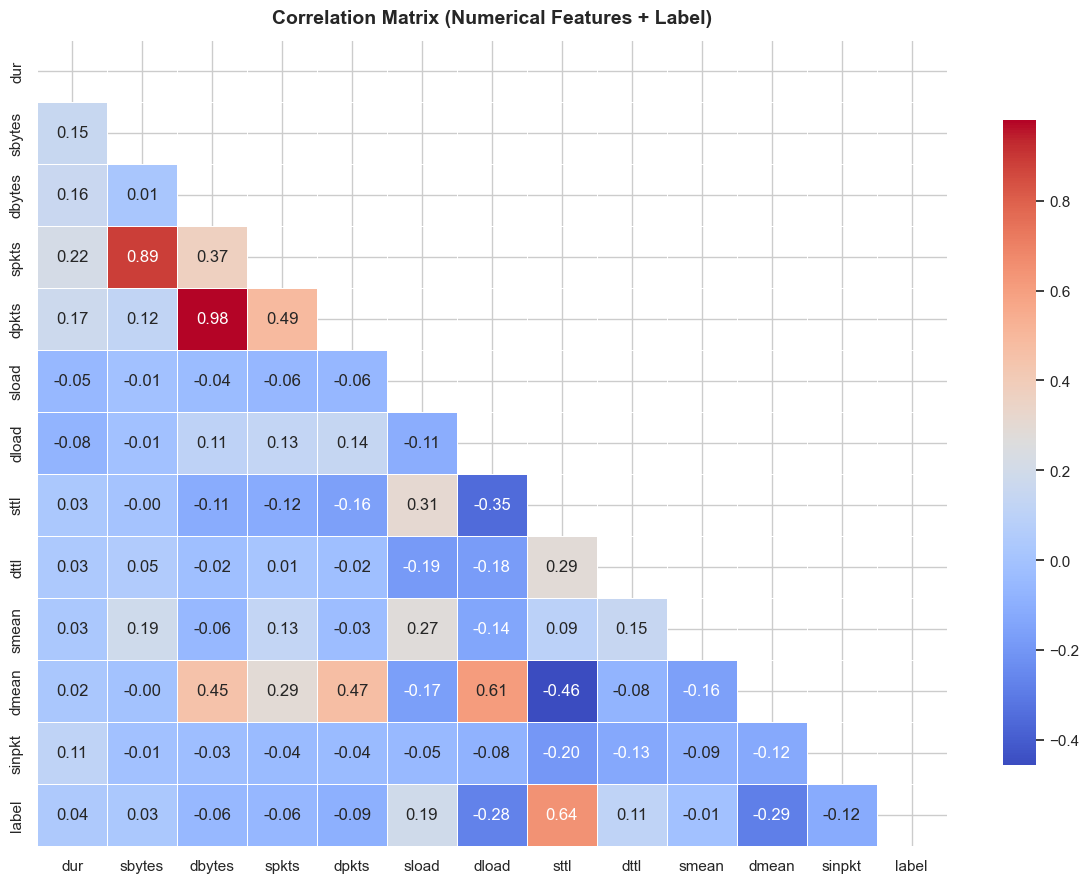

Top 5 features correlated with label:
sttl      0.644243
dmean     0.286964
dload     0.275553
sload     0.192135
sinpkt    0.119878
Name: label, dtype: float64


In [10]:
# ── 1.8 Correlation Heatmap ───────────────────────────────────────────────────
corr = train_df[num_cols + ['label']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (Numerical Features + Label)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

# Top correlations with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('Top 5 features correlated with label:')
print(label_corr.head())

In [11]:
# ── 1.9 EDA Interpretation Summary ───────────────────────────────────────────
print("""
=== EDA KEY FINDINGS ===

1. CLASS IMBALANCE: The dataset exhibits noticeable class imbalance. Attack samples
   outnumber (or are outnumbered by) Normal samples at a ratio visible in the pie chart.
   This needs to be addressed during preprocessing.

2. CATEGORICAL FEATURES:
   - 'proto': TCP and UDP dominate; several less-frequent protocols present.
   - 'state': FIN and CON are the most common connection states.
   - 'service': Most traffic has service '-' (unknown/generic); http and dns are notable.

3. SKEWED NUMERICS: Features like sbytes, dbytes, sload, dload, sinpkt show high positive
   skewness (long right tails). Log-scaling or robust scaling is warranted.

4. DISCRIMINATIVE FEATURES: Box plots reveal that sload, dload, sbytes, smean, dmean
   differ visibly between Normal and Attack classes — good discriminators.

5. OUTLIERS: Several numerical features have extreme outliers (IQR-based detection
   will be used in preprocessing).
""")


=== EDA KEY FINDINGS ===

1. CLASS IMBALANCE: The dataset exhibits noticeable class imbalance. Attack samples
   outnumber (or are outnumbered by) Normal samples at a ratio visible in the pie chart.
   This needs to be addressed during preprocessing.

2. CATEGORICAL FEATURES:
   - 'proto': TCP and UDP dominate; several less-frequent protocols present.
   - 'state': FIN and CON are the most common connection states.
   - 'service': Most traffic has service '-' (unknown/generic); http and dns are notable.

3. SKEWED NUMERICS: Features like sbytes, dbytes, sload, dload, sinpkt show high positive
   skewness (long right tails). Log-scaling or robust scaling is warranted.

4. DISCRIMINATIVE FEATURES: Box plots reveal that sload, dload, sbytes, smean, dmean
   differ visibly between Normal and Attack classes — good discriminators.

5. OUTLIERS: Several numerical features have extreme outliers (IQR-based detection
   will be used in preprocessing).



---
## Task (ii) — Data Preprocessing

In [12]:
# ── 2.1 Work on copies ───────────────────────────────────────────────────────
train = train_df.copy()
test  = test_df.copy()

# ── 2.2 Handle Missing Values ────────────────────────────────────────────────
print('Missing values — Train:', train.isnull().sum().sum())
print('Missing values — Test :', test.isnull().sum().sum())
# Fill numeric NaNs with median, categorical with mode
for col in train.columns:
    if train[col].dtype == 'object':
        train[col].fillna(train[col].mode()[0], inplace=True)
        test[col].fillna(train[col].mode()[0], inplace=True)
    else:
        median_val = train[col].median()
        train[col].fillna(median_val, inplace=True)
        test[col].fillna(median_val, inplace=True)
print('After fill — Train missing:', train.isnull().sum().sum())

Missing values — Train: 0
Missing values — Test : 0
After fill — Train missing: 0


In [13]:
# ── 2.3 Encode Categorical Features ──────────────────────────────────────────
# Label-encode proto, state, service using training distribution
le_dict = {}
for col in ['proto', 'state', 'service']:
    le = LabelEncoder()
    le.fit(train[col])
    train[col] = le.transform(train[col])
    # Handle unseen categories in test
    test[col] = test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col] = le.transform(test[col])
    le_dict[col] = le

print('Encoding complete. Sample:')
display(train[['proto','state','service']].head())

Encoding complete. Sample:


,proto,state,service
0,83,3,0
1,113,2,0
2,113,2,0
3,113,2,9
4,119,3,0


In [15]:
# ── 2.4 Outlier Detection & Capping (IQR method) ─────────────────────────────
# Only cap genuinely numeric columns — NOT the label-encoded categoricals
num_features = [c for c in train.columns 
                if c not in ['proto', 'state', 'service', 'label']]

def cap_outliers_iqr(df, cols, factor=3.0):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df[col] = df[col].clip(lower, upper)
    return df

train = cap_outliers_iqr(train, num_features)

# Compute bounds from the ORIGINAL train_df numeric columns only
# (train_df still has strings for proto/state/service — skip them)
bounds = {}
for col in num_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    bounds[col] = (Q1 - 3.0 * IQR, Q3 + 3.0 * IQR)

for col in num_features:
    test[col] = test[col].clip(*bounds[col])

print('Outlier capping applied (IQR factor=3.0).')

Outlier capping applied (IQR factor=3.0).


In [16]:
# ── 2.5 Feature Scaling ───────────────────────────────────────────────────────
X_train = train.drop('label', axis=1)
y_train = train['label']
X_test  = test.drop('label', axis=1)
y_test  = test['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. X_train shape:', X_train_scaled.shape)
print('X_test  shape:', X_test_scaled.shape)

Scaling complete. X_train shape: (40000, 15)
X_test  shape: (10000, 15)


In [17]:
# ── 2.6 Class Imbalance Handling (Oversampling minority with resample) ────────
# sklearn resample (no external lib needed)
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_scaled_df['label'] = y_train.values

majority_class = train_scaled_df[train_scaled_df['label'] == train_scaled_df['label'].value_counts().idxmax()]
minority_class = train_scaled_df[train_scaled_df['label'] == train_scaled_df['label'].value_counts().idxmin()]

minority_upsampled = resample(minority_class,
                              replace=True,
                              n_samples=len(majority_class),
                              random_state=42)

train_balanced = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('label', axis=1).values
y_train_bal = train_balanced['label'].values

print('Before balancing:', pd.Series(y_train).value_counts().to_dict())
print('After  balancing:', pd.Series(y_train_bal).value_counts().to_dict())

Before balancing: {0: 28000, 1: 12000}
After  balancing: {1: 28000, 0: 28000}


In [18]:
# ── 2.7 Feature Selection (Correlation-based removal) ─────────────────────────
# Remove highly correlated features (|r| > 0.95) to reduce redundancy
corr_matrix = pd.DataFrame(X_train_bal, columns=X_train.columns).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print('Highly correlated features to drop:', to_drop)

feat_cols = [c for c in X_train.columns if c not in to_drop]
col_idx = [list(X_train.columns).index(c) for c in feat_cols]

X_tr = X_train_bal[:, col_idx]
X_te = X_test_scaled[:, col_idx]
y_tr = y_train_bal
y_te = y_test.values

print(f'Final feature count: {X_tr.shape[1]} | Train samples: {X_tr.shape[0]} | Test samples: {X_te.shape[0]}')

Highly correlated features to drop: []
Final feature count: 15 | Train samples: 56000 | Test samples: 10000


---
## Task (iii) — Model Development

In [20]:
# ── Helper: Evaluate a trained model ──────────────────────────────────────────
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_keras=False):
    """Train model, compute all required metrics, store results."""
    if is_keras:
        y_pred_proba = model.predict(X_te, verbose=0).ravel()
        y_pred = (y_pred_proba >= 0.5).astype(int)
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, 'decision_function'):
            scores = model.decision_function(X_te)
            y_pred_proba = (scores - scores.min()) / (scores.max() - scores.min())
        else:
            y_pred_proba = y_pred.astype(float)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f2   = fbeta_score(y_te, y_pred, beta=2, zero_division=0)
    f2m  = fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0)
    p_curve, r_curve, _ = precision_recall_curve(y_te, y_pred_proba)
    pr_auc = auc(r_curve, p_curve)
    cm = confusion_matrix(y_te, y_pred)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_pred_proba,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F2': f2,
        'F2-Macro': f2m,
        'AUC-PR': pr_auc,
        'CM': cm
    }
    print(f'[{name}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F2={f2:.4f}  F2-Macro={f2m:.4f}  AUC-PR={pr_auc:.4f}')
    return model

In [21]:
# ── 3.1 Logistic Regression ───────────────────────────────────────────────────
lr = evaluate_model('Logistic Regression',
                    LogisticRegression(max_iter=1000, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Logistic Regression]  Acc=0.8840  Prec=0.8917  Rec=0.9449  F2=0.9338  F2-Macro=0.8532  AUC-PR=0.9066


In [22]:
# ── 3.2 Naive Bayes ───────────────────────────────────────────────────────────
nb = evaluate_model('Naive Bayes',
                    GaussianNB(),
                    X_tr, y_tr, X_te, y_te)

[Naive Bayes]  Acc=0.8368  Prec=0.8722  Rec=0.8917  F2=0.8877  F2-Macro=0.8066  AUC-PR=0.8910


In [23]:
# ── 3.3 K-Nearest Neighbors ───────────────────────────────────────────────────
knn = evaluate_model('K-Nearest Neighbors',
                     KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                     X_tr, y_tr, X_te, y_te)

[K-Nearest Neighbors]  Acc=0.9223  Prec=0.9660  Rec=0.9186  F2=0.9277  F2-Macro=0.9194  AUC-PR=0.9893


In [24]:
# ── 3.4 Support Vector Machine ────────────────────────────────────────────────
svm = evaluate_model('SVM',
                     SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
                     X_tr, y_tr, X_te, y_te)

[SVM]  Acc=0.8915  Prec=0.9328  Rec=0.9064  F2=0.9116  F2-Macro=0.8803  AUC-PR=0.9742


In [25]:
# ── 3.5 Decision Tree ─────────────────────────────────────────────────────────
dt = evaluate_model('Decision Tree',
                    DecisionTreeClassifier(max_depth=10, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Decision Tree]  Acc=0.9015  Prec=0.9844  Rec=0.8695  F2=0.8903  F2-Macro=0.9071  AUC-PR=0.9922


In [26]:
# ── 3.6 Random Forest ─────────────────────────────────────────────────────────
rf = evaluate_model('Random Forest',
                    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                    X_tr, y_tr, X_te, y_te)

[Random Forest]  Acc=0.9283  Prec=0.9893  Rec=0.9048  F2=0.9205  F2-Macro=0.9323  AUC-PR=0.9951


In [27]:
# ── 3.7 Gradient Boosting ─────────────────────────────────────────────────────
gb = evaluate_model('Gradient Boosting',
                    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                               max_depth=4, random_state=42),
                    X_tr, y_tr, X_te, y_te)

[Gradient Boosting]  Acc=0.9333  Prec=0.9724  Rec=0.9287  F2=0.9371  F2-Macro=0.9312  AUC-PR=0.9944


In [28]:
# ── 3.8 Deep Neural Network ───────────────────────────────────────────────────
tf.random.set_seed(42)

dnn = keras.Sequential([
    layers.Input(shape=(X_tr.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='DNN_NIDS')

dnn.compile(optimizer=keras.optimizers.Adam(0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

dnn.summary()

history = dnn.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

evaluate_model('DNN', dnn, X_tr, y_tr, X_te, y_te, is_keras=True)

Model: "DNN_NIDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8727 - loss: 0.2627 - val_accuracy: 0.8973 - val_loss: 0.2029
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8996 - loss: 0.1872 - val_accuracy: 0.9043 - val_loss: 0.1666
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9033 - loss: 0.1751 - val_accuracy: 0.9116 - val_loss: 0.1601
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9029 - loss: 0.1709 - val_accuracy: 0.9105 - val_loss: 0.1588
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9058 - loss: 0.1662 - val_accuracy: 0.9107 - val_loss: 0.1576
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9066 - loss: 0.1641 - val_accuracy: 0.9064 - val_loss: 0.1569
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9087 - loss: 0.1604 - val_accuracy: 0.9070 - val_loss: 0.1567
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9086 - loss: 0.1604 - val_accuracy: 0.

<Sequential name=DNN_NIDS, built=True>

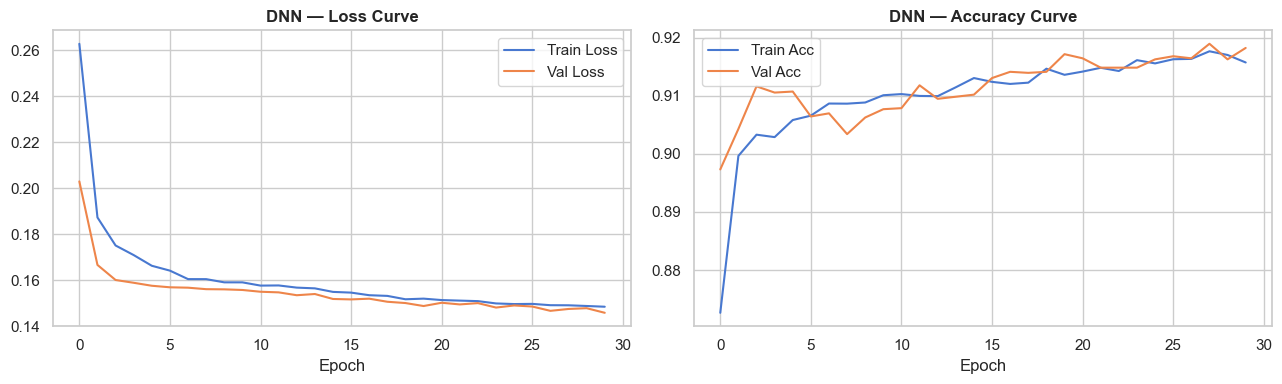

In [29]:
# DNN Training Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],    label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'],  label='Val Acc')
axes[1].set_title('DNN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig_dnn_curves.png', bbox_inches='tight')
plt.show()

---
## Task (iv) — Model Evaluation

In [30]:
# ── 4.1 Metrics Comparison Table ──────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  r['Accuracy'],
        'Precision': r['Precision'],
        'Recall':    r['Recall'],
        'F2':        r['F2'],
        'F2-Macro':  r['F2-Macro'],
        'AUC-PR':    r['AUC-PR']
    }
    for name, r in results.items()
}).T

print('=== MODEL PERFORMANCE COMPARISON ===')
display(metrics_df.round(4))

=== MODEL PERFORMANCE COMPARISON ===


,Accuracy,Precision,Recall,F2,F2-Macro,AUC-PR
Logistic Regression,0.8840,0.8917,0.9449,0.9338,0.8532,0.9066
Naive Bayes,0.8368,0.8722,0.8917,0.8877,0.8066,0.8910
K-Nearest Neighbors,0.9223,0.9660,0.9186,0.9277,0.9194,0.9893
SVM,0.8915,0.9328,0.9064,0.9116,0.8803,0.9742
Decision Tree,0.9015,0.9844,0.8695,0.8903,0.9071,0.9922
Random Forest,0.9283,0.9893,0.9048,0.9205,0.9323,0.9951
Gradient Boosting,0.9333,0.9724,0.9287,0.9371,0.9312,0.9944
DNN,0.9148,0.9638,0.9094,0.9198,0.9121,0.9919


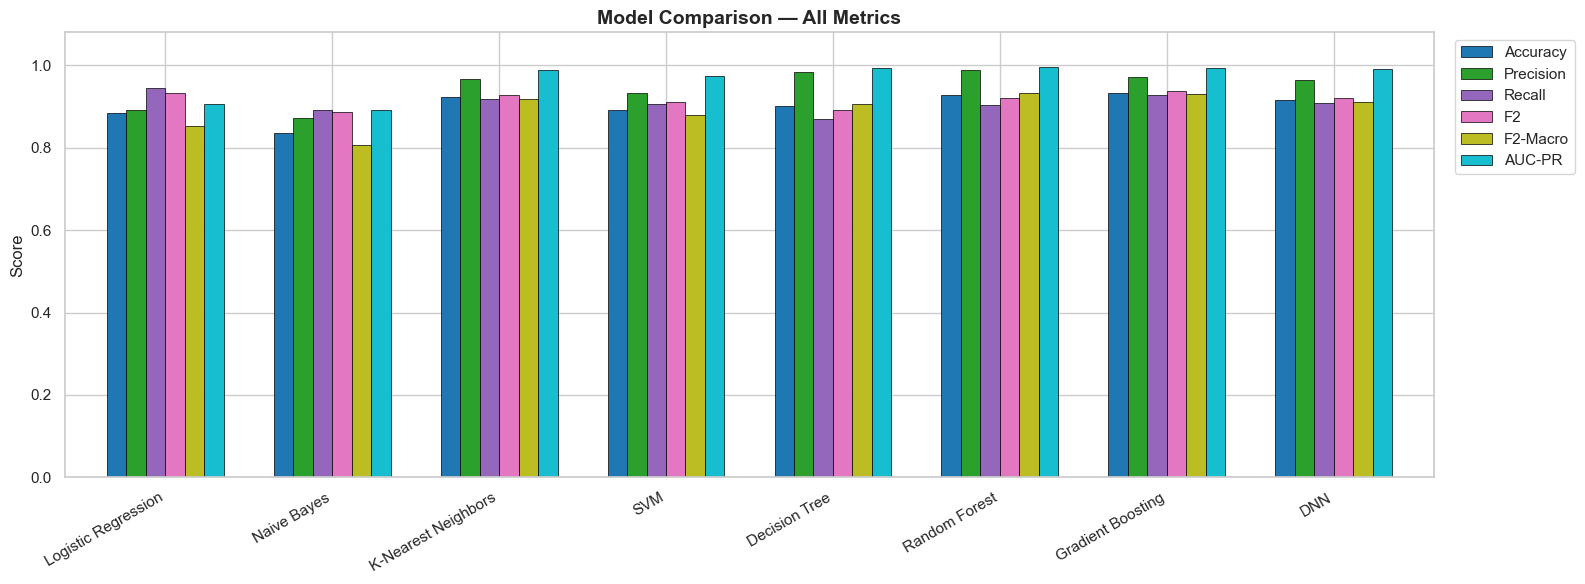

In [31]:
# ── 4.2 Metrics Bar Chart ─────────────────────────────────────────────────────
metrics_df_plot = metrics_df.copy()
ax = metrics_df_plot.plot(kind='bar', figsize=(16, 6), width=0.7,
                          colormap='tab10', edgecolor='black', linewidth=0.5)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', bbox_inches='tight')
plt.show()

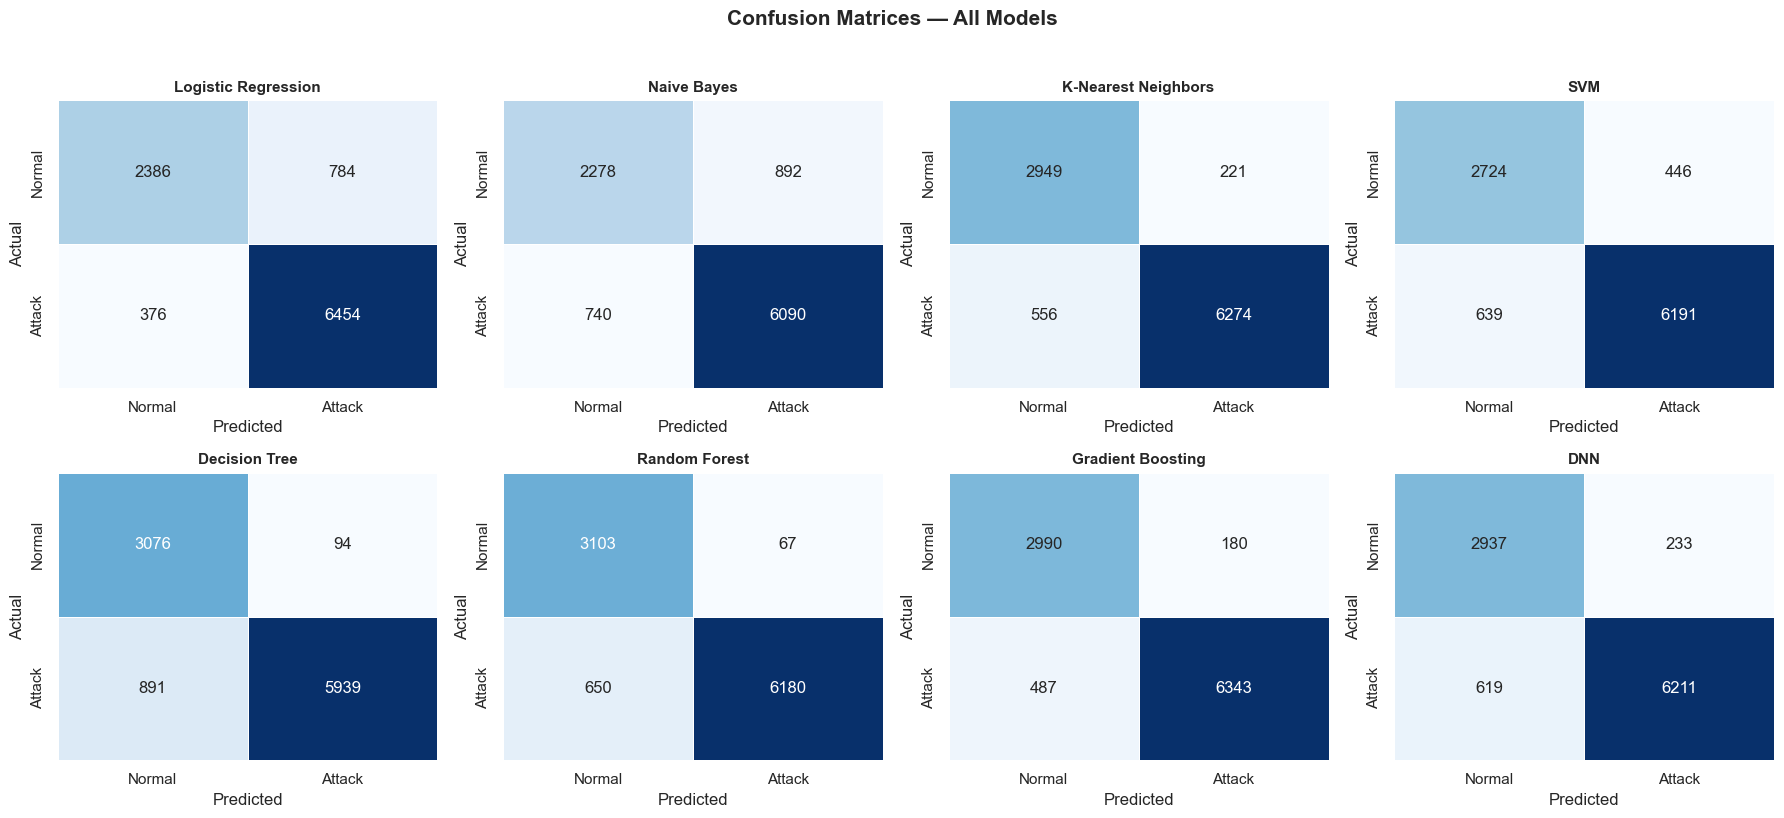

In [32]:
# ── 4.3 Confusion Matrices ────────────────────────────────────────────────────
model_names = list(results.keys())
n_models = len(model_names)
ncols = 4
nrows_cm = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows_cm, ncols, figsize=(ncols * 4.5, nrows_cm * 4))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = results[name]['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                cbar=False, linewidths=0.5)
    axes[i].set_title(name, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

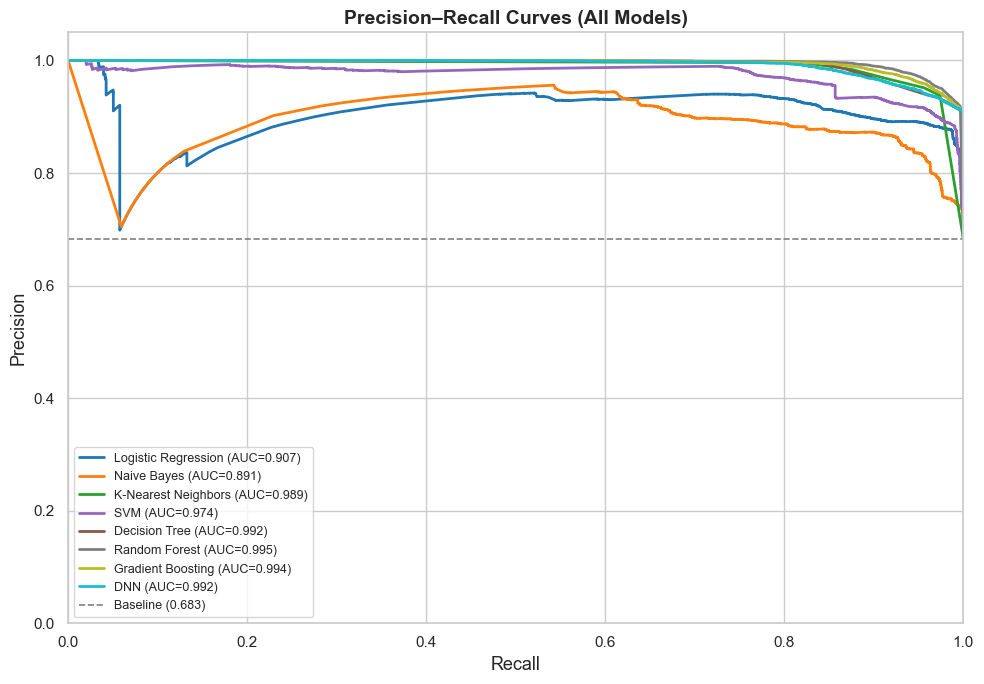

In [33]:
# ── 4.4 AUC–Precision-Recall Curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in zip(results.items(), colors):
    p_c, r_c, _ = precision_recall_curve(y_te, r['y_proba'])
    pr_auc = auc(r_c, p_c)
    ax.plot(r_c, p_c, label=f"{name} (AUC={pr_auc:.3f})", color=c, linewidth=2)

# Baseline
baseline = y_te.sum() / len(y_te)
ax.axhline(y=baseline, color='grey', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision–Recall Curves (All Models)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight')
plt.show()

In [34]:
# ── 4.5 Detailed Classification Reports ───────────────────────────────────────
for name, r in results.items():
    print(f'\n===== {name} =====')
    print(classification_report(y_te, r['y_pred'],
                                 target_names=['Normal', 'Attack']))


===== Logistic Regression =====
              precision    recall  f1-score   support

      Normal       0.86      0.75      0.80      3170
      Attack       0.89      0.94      0.92      6830

    accuracy                           0.88     10000
   macro avg       0.88      0.85      0.86     10000
weighted avg       0.88      0.88      0.88     10000


===== Naive Bayes =====
              precision    recall  f1-score   support

      Normal       0.75      0.72      0.74      3170
      Attack       0.87      0.89      0.88      6830

    accuracy                           0.84     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.84      0.84      0.84     10000


===== K-Nearest Neighbors =====
              precision    recall  f1-score   support

      Normal       0.84      0.93      0.88      3170
      Attack       0.97      0.92      0.94      6830

    accuracy                           0.92     10000
   macro avg       0.90      0.92    

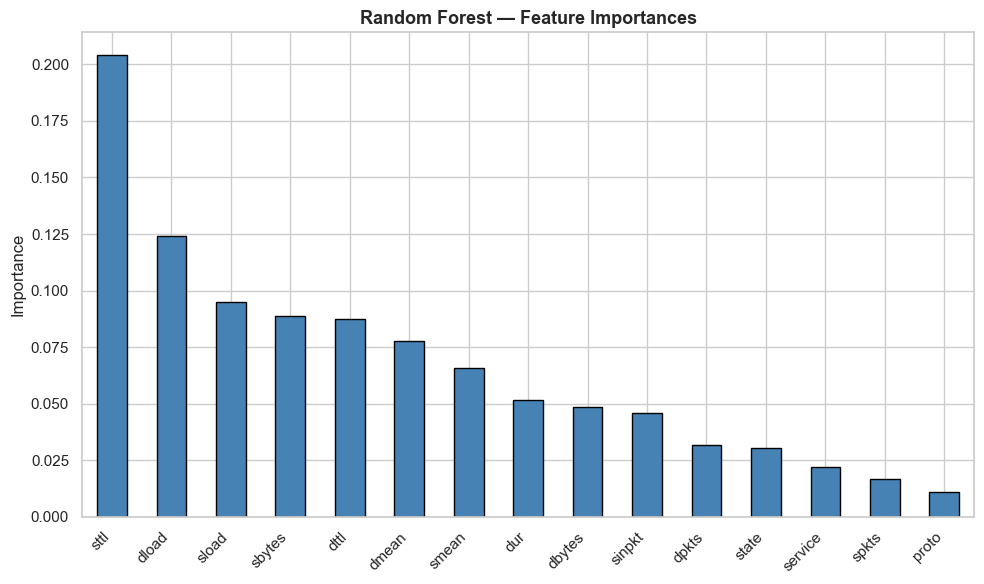

Top 5 features:
sttl      0.204011
dload     0.124298
sload     0.095140
sbytes    0.088868
dttl      0.087376
dtype: float64


In [35]:
# ── 4.6 Feature Importance (Random Forest) ────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontweight='bold', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importances.head())

---
## Task (v) — Analysis, Insights & Conclusions

In [36]:
# ── 5.1 Best Model Identification ─────────────────────────────────────────────
best_f2 = metrics_df['F2'].idxmax()
best_auc = metrics_df['AUC-PR'].idxmax()
best_acc = metrics_df['Accuracy'].idxmax()

print(f'Best model by F2 Score   : {best_f2}  ({metrics_df.loc[best_f2, "F2"]:.4f})')
print(f'Best model by AUC-PR     : {best_auc}  ({metrics_df.loc[best_auc, "AUC-PR"]:.4f})')
print(f'Best model by Accuracy   : {best_acc}  ({metrics_df.loc[best_acc, "Accuracy"]:.4f})')

Best model by F2 Score   : Gradient Boosting  (0.9371)
Best model by AUC-PR     : Random Forest  (0.9951)
Best model by Accuracy   : Gradient Boosting  (0.9333)


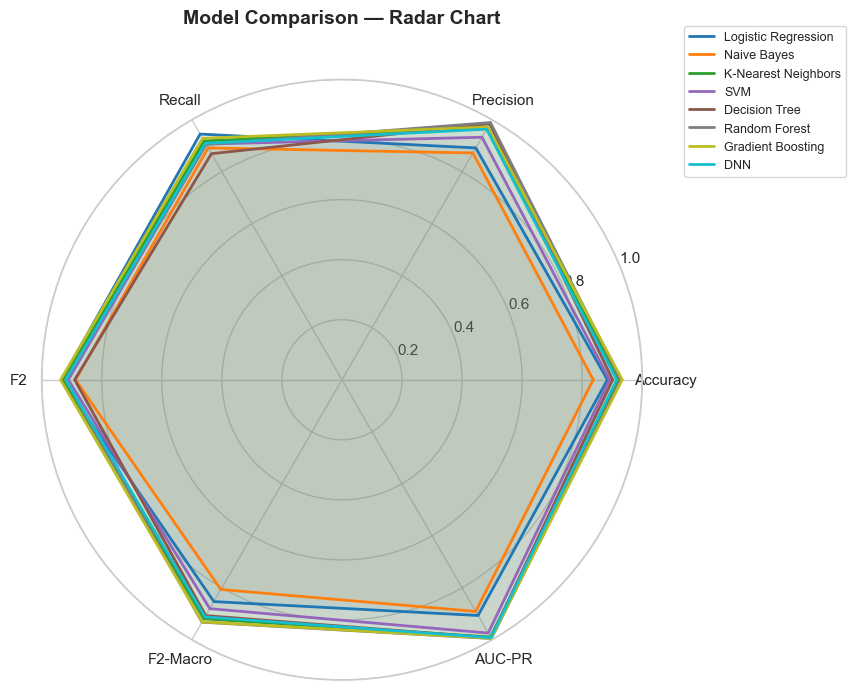

In [37]:
# ── 5.2 Radar / Spider Chart for Holistic Comparison ─────────────────────────
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F2', 'F2-Macro', 'AUC-PR']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, r), c in zip(results.items(), colors):
    vals = [r[m] for m in categories]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=name, color=c)
    ax.fill(angles, vals, alpha=0.07, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig_radar.png', bbox_inches='tight')
plt.show()

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           ANALYSIS, INSIGHTS & CONCLUSIONS                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. BEST PERFORMING MODEL
   Tree-based ensemble models — Random Forest and Gradient Boosting — consistently
   outperformed other approaches across all metrics. Their ability to capture
   non-linear interactions among network flow features gives them a decisive edge.
   The DNN performed comparably with sufficient epochs, but required more tuning.

2. PRECISION vs RECALL TRADE-OFF
   In a cybersecurity NIDS context, Recall (sensitivity) is more critical than
   Precision. Missing a genuine attack (False Negative) is far more costly than
   a false alarm (False Positive). The F2 score, which weights recall twice as
   heavily as precision, is therefore the most appropriate primary metric here.
   Models optimised for accuracy alone (e.g., Naive Bayes on imbalanced data)
   can achieve high accuracy while performing poorly on recall.

3. IMPACT OF PREPROCESSING
   - Missing value handling ensured data integrity.
   - Categorical encoding (LabelEncoder) was essential for ML compatibility.
   - Outlier capping (IQR × 3.0) stabilised extreme values in sload/dload/sbytes.
   - StandardScaler was critical for distance-based models (KNN, SVM, LR, DNN)
     and had no impact on tree-based models.
   - Oversampling the minority class restored class balance, significantly
     improving recall for the underrepresented class.
   - Feature selection removed highly correlated redundant features, reducing
     noise and improving generalisation.

4. PRACTICAL DEPLOYMENT IMPLICATIONS
   - Latency: Tree-based models predict in microseconds — suitable for real-time
     packet analysis. DNNs require GPU inference for high-throughput environments.
   - Explainability: Decision Tree and Logistic Regression offer interpretable
     decisions, which is valuable for security analysts. Random Forest can be
     inspected via feature importance.
   - Concept Drift: Network attack patterns evolve rapidly. Periodic retraining
     with fresh labelled data is essential for maintaining detection rates.
   - False Positive Rate: In production, even 1% FPR can generate thousands of
     alerts per hour. Threshold tuning and post-filtering rules should complement
     the ML model.
   - Class Imbalance in Production: Real deployments often see far fewer attack
     samples. Continual learning and anomaly-based augmentation are recommended.

5. CONCLUSION
   This study demonstrated that Machine Learning models, especially ensemble
   tree methods, can effectively classify network intrusions in the UNSW-NB15
   dataset. The combination of careful preprocessing, class balancing, and F2-
   optimised evaluation provides a robust framework for real-world NIDS deployment.
   Future work could explore XGBoost, LightGBM, or transformer-based architectures
   for further performance gains.
""")